In [13]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 2. Load Dataset
df = pd.read_csv(r'C:\Users\sidha\OneDrive\Desktop\resume\Project\ML Project\predictive_maintenance.csv')

In [15]:
# 3. Basic Info
print(df.head())


   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


In [16]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None


In [17]:

print(df.describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]        Target  
count            10000.000000  10000.000000     10000.000000  10000.000000  
mean              1538.776100     39.986910       107.951000      0.033900  
std                179.284096      9.968934        63.654147      0.180981  
min               1168.000000      3.800000         0.000000      0.000000  
25

In [18]:
# 4. Data Cleaning
# Check missing values
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [19]:
# Drop duplicates
df = df.drop_duplicates()

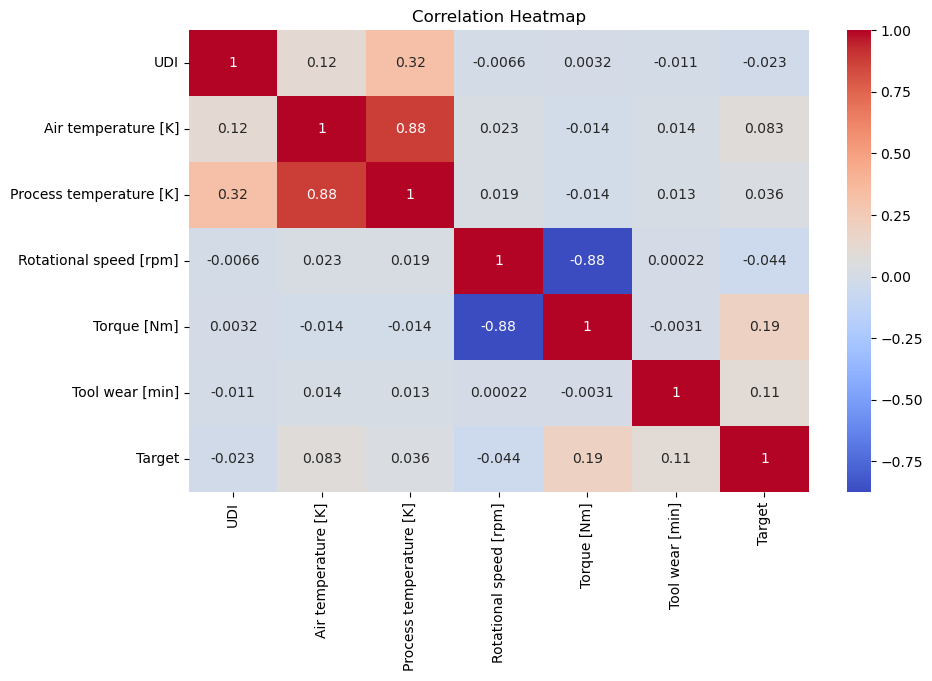

In [20]:
# 5. Exploratory Data Analysis (EDA)

# Correlation Heatmap


numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

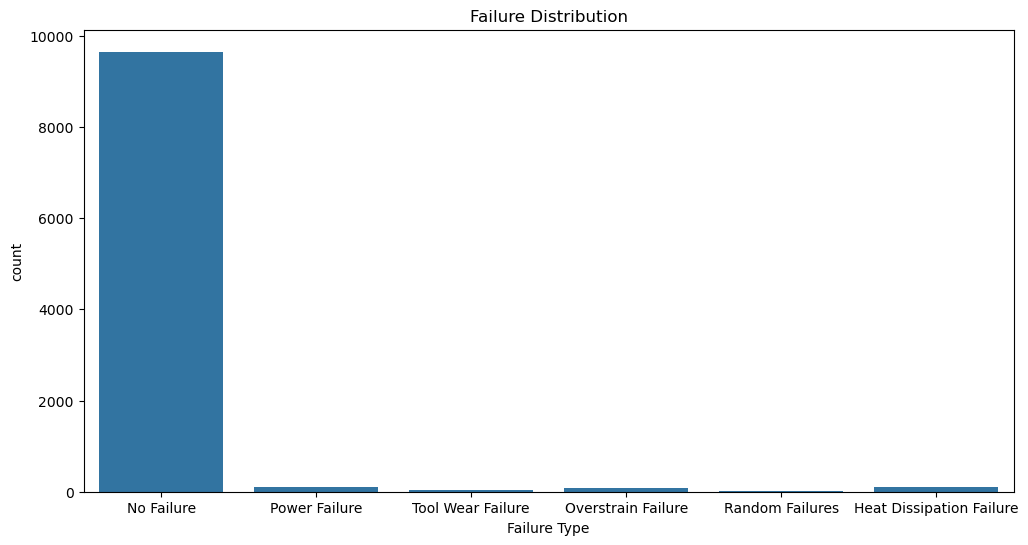

In [21]:
# Failure Distribution
plt.figure(figsize=(12,6))
sns.countplot(x='Failure Type', data=df)
plt.title("Failure Distribution")
plt.show()

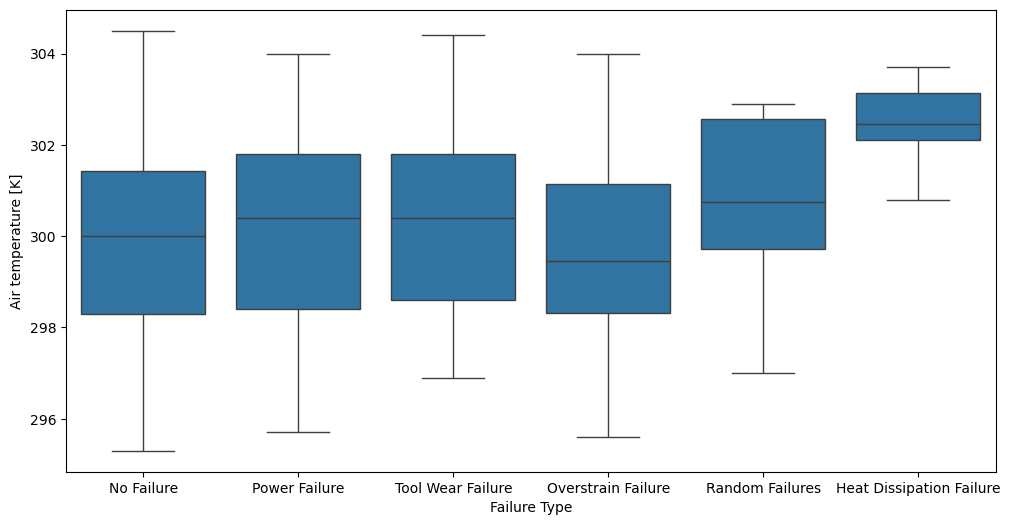

In [22]:

# Feature vs Failure
plt.figure(figsize=(12,6))
sns.boxplot(x='Failure Type', y='Air temperature [K]', data=df)
plt.show()

In [23]:
# 6. Key Insights
# Example: Group analysis
failure_analysis = df.groupby('Failure Type').mean(numeric_only=True)
print(failure_analysis)


                                  UDI  Air temperature [K]  \
Failure Type                                                 
Heat Dissipation Failure  4407.750000           302.567857   
No Failure                5013.873601           299.972855   
Overstrain Failure        4902.987179           299.867949   
Power Failure             4306.136842           300.075789   
Random Failures           4661.833333           300.766667   
Tool Wear Failure         5377.666667           300.288889   

                          Process temperature [K]  Rotational speed [rpm]  \
Failure Type                                                                
Heat Dissipation Failure               310.799107             1337.964286   
No Failure                             309.994343             1540.324389   
Overstrain Failure                     310.051282             1354.243590   
Power Failure                          309.954737             1763.968421   
Random Failures                        31

In [24]:
# 7. (Optional) Simple Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features & Target
X = df.drop(['Product ID', 'Type', 'Failure Type', 'Target'], axis=1)
y = df['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.9675


In [29]:
import os

os.makedirs("models", exist_ok=True)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [31]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv(r'C:\Users\sidha\OneDrive\Desktop\resume\Project\ML Project\predictive_maintenance.csv')

# Drop unnecessary columns
df = df.drop(["UDI", "Product ID", "Failure Type"], axis=1)

# Convert Type column to numeric
df["Type"] = df["Type"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

# Features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Accuracy
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model Accuracy: 0.9845
Model saved successfully
